<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/gasvaluechain/energystatistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Natural gas and the World Energy Outlook

**Evidence, scenarios, LNG supply, and an end-to-end NeqSim infrastructure screen**

This notebook is for energy analysts, process engineers, and students who want to connect
public energy statistics to reproducible thermodynamic and process calculations.

## Audience, prerequisites, and learning objectives

You should be comfortable with Python tables and plots. No previous NeqSim experience is
required.

By the end, you will be able to:

1. distinguish observations, forecasts, scenarios, and engineering stress cases;
2. reproduce selected 2024–2025 gas-market indicators from dated IEA publications;
3. explain the WEO 2025 CPS, STEPS, and NZE scenario roles without treating them as forecasts;
4. quantify the announced LNG supply expansion to 2030;
5. build and flash a multicomponent gas in NeqSim;
6. calculate ISO 6976 calorific values and Wobbe index;
7. construct a three-stage intercooled compression process;
8. close mass and energy balances; and
9. translate a bcm/year scenario into power, energy, and emissions screens.

## Evidence date and scope

The evidence snapshot is **23 July 2026**. The principal public sources are:

- IEA, *World Energy Outlook 2025* (WEO 2025);
- IEA, *Gas 2025*;
- IEA, *Global Energy Review 2026*; and
- IEA, *Global Methane Tracker 2026*.

The notebook embeds a small, transparent dataset so execution does not depend on a fragile
download. Values are rounded exactly as reported on the cited public pages. They are not a
substitute for licensed WEO datasets or project-specific market analysis.

In [1]:
import importlib.metadata
import os
import subprocess
import sys

if "COLAB_RELEASE_TAG" in os.environ:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ]
    )

neqsim_version = importlib.metadata.version("neqsim")

print(f"NeqSim version: {neqsim_version}")
print(f"Python version: {sys.version.split()[0]}")

NeqSim version: 3.16.0
Python version: 3.12.13


In [2]:
import math
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from neqsim.process import compressor, cooler, newProcess, stream
from neqsim.thermo import ISO6976, TPflash, fluid

plt.style.use("seaborn-v0_8-whitegrid")

COLORS = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "red": "#D55E00",
    "purple": "#CC79A7",
    "grey": "#666666",
    "sky": "#56B4E9",
}

print(f"Platform: {platform.platform()}")

Platform: Linux-6.12.13-x86_64-with-glibc2.39


## 1. How to read energy statistics

Four evidence types are kept separate:

- an **observation** describes a measured historical period;
- an **estimate** fills incomplete recent data;
- a **forecast** is a near-term expected outcome;
- a **scenario** is a conditional pathway based on assumptions.

WEO scenarios are not probability-weighted predictions. Comparing CPS, STEPS, and NZE
reveals how policy and technology assumptions change outcomes.

In [3]:
evidence_register = pd.DataFrame(
    [
        {
            "indicator": "Global gas-demand growth",
            "period": "2024",
            "value": 2.8,
            "unit": "%",
            "evidence_type": "estimate",
            "source": "IEA Global Energy Review 2026",
        },
        {
            "indicator": "Global gas-demand growth",
            "period": "2025",
            "value": 1.0,
            "unit": "%",
            "evidence_type": "estimate",
            "source": "IEA Global Energy Review 2026",
        },
        {
            "indicator": "Global gas-demand increase",
            "period": "2025",
            "value": 40.0,
            "unit": "bcm",
            "evidence_type": "estimate",
            "source": "IEA Global Energy Review 2026",
        },
        {
            "indicator": "New LNG export capacity",
            "period": "2025–2030",
            "value": 300.0,
            "unit": "bcm/year",
            "evidence_type": "project pipeline",
            "source": "IEA WEO 2025 and Gas 2025",
        },
        {
            "indicator": "Net LNG supply increase",
            "period": "2024–2030",
            "value": 250.0,
            "unit": "bcm/year",
            "evidence_type": "forecast",
            "source": "IEA Gas 2025",
        },
    ]
)

display(evidence_register)
assert evidence_register["value"].notna().all()

,indicator,period,value,unit,evidence_type,source
0,Global gas-demand growth,2024,2.8,%,estimate,IEA Global Energy Review 2026
1,Global gas-demand growth,2025,1.0,%,estimate,IEA Global Energy Review 2026
2,Global gas-demand increase,2025,40.0,bcm,estimate,IEA Global Energy Review 2026
3,New LNG export capacity,2025–2030,300.0,bcm/year,project pipeline,IEA WEO 2025 and Gas 2025
4,Net LNG supply increase,2024–2030,250.0,bcm/year,forecast,IEA Gas 2025


## 2. Present market: growth slowed sharply in 2025

The IEA estimates that global gas demand grew by 2.8% in 2024 and 1.0% in 2025. The latter
was about 40 bcm. Weather lifted buildings demand in the United States and European Union,
while high LNG prices and rapid renewable growth constrained several Asian markets.

The inferred 2024 global-demand scale below is a consistency check, not a replacement for
the IEA balance:

$$
D_{2024} = \frac{\Delta D_{2025}}{g_{2025}}
$$

$D$ is gas demand in bcm and $g$ is fractional annual growth.

In [4]:
demand_increase_2025_bcm = 40.0
demand_growth_2025 = 0.01
inferred_demand_2024_bcm = demand_increase_2025_bcm / demand_growth_2025
inferred_demand_2025_bcm = (
    inferred_demand_2024_bcm + demand_increase_2025_bcm
)
inferred_demand_2023_bcm = inferred_demand_2024_bcm / 1.028

global_demand_check = pd.DataFrame(
    {
        "year": [2023, 2024, 2025],
        "demand_bcm": [
            inferred_demand_2023_bcm,
            inferred_demand_2024_bcm,
            inferred_demand_2025_bcm,
        ],
        "status": [
            "back-calculated",
            "inferred scale",
            "inferred scale",
        ],
    }
)

display(global_demand_check.round(1))

assert math.isclose(
    inferred_demand_2025_bcm - inferred_demand_2024_bcm,
    40.0,
)

,year,demand_bcm,status
0,2023,3891.1,back-calculated
1,2024,4000.0,inferred scale
2,2025,4040.0,inferred scale


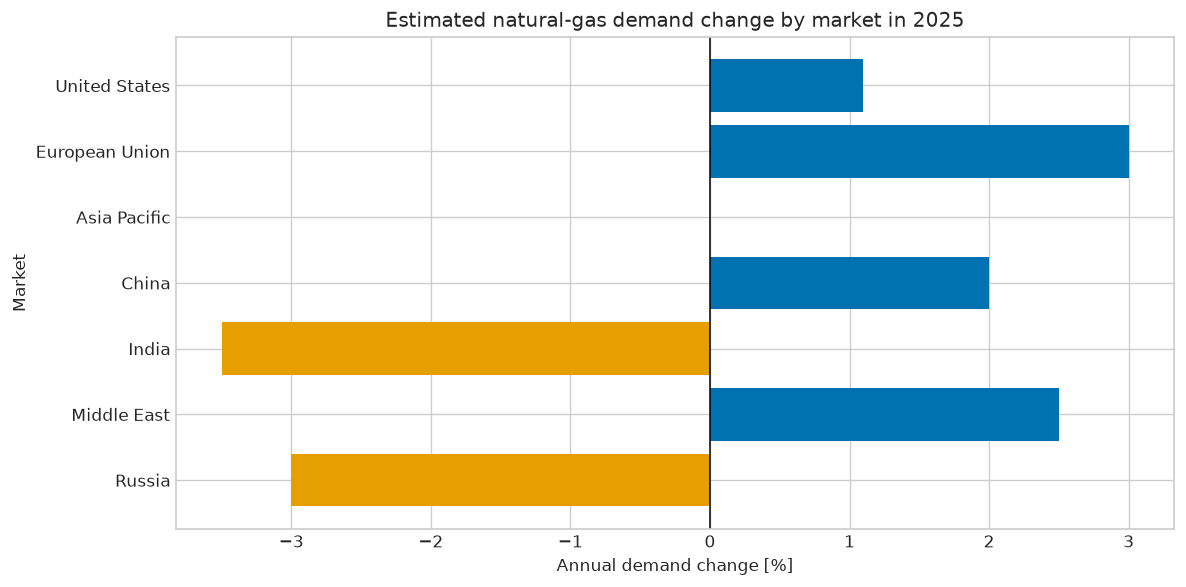

In [5]:
regional_growth_2025 = pd.DataFrame(
    {
        "region": [
            "United States",
            "European Union",
            "Asia Pacific",
            "China",
            "India",
            "Middle East",
            "Russia",
        ],
        "growth_percent": [
            1.1,
            3.0,
            0.0,
            2.0,
            -3.5,
            2.5,
            -3.0,
        ],
    }
)

bar_colors = [
    COLORS["blue"] if value >= 0.0 else COLORS["orange"]
    for value in regional_growth_2025["growth_percent"]
]

fig, ax = plt.subplots(figsize=(10.0, 5.0))
ax.barh(
    regional_growth_2025["region"],
    regional_growth_2025["growth_percent"],
    color=bar_colors,
)
ax.axvline(0.0, color="black", linewidth=0.9)
ax.set_title("Estimated natural-gas demand change by market in 2025")
ax.set_xlabel("Annual demand change [%]")
ax.set_ylabel("Market")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Interpretation.** A single global growth rate hides divergent regional conditions.
Weather, affordability, industrial activity, renewable output, and nuclear availability
moved gas demand in different directions. This is why an engineering project should be
stress-tested rather than sized from one central demand number.

## 3. What WEO 2025 scenarios say

- **CPS** reflects policies already in force. WEO 2025 says natural-gas demand continues
  growing to mid-century.
- **STEPS** also considers announced policies and implementation prospects. Gas demand
  increases nearly 1% per year to 2035, then levels off.
- **NZE** is a normative pathway to net-zero energy-sector emissions by 2050, with rapid
  efficiency, electrification, low-emissions supply, and methane abatement.

The next cell converts the public STEPS statement into an index. The other two curves are
explicitly labelled **engineering stress cases**, not digitised IEA scenario data.

In [6]:
scenario_years = np.arange(2025, 2051)


def compound_index(years, first_rate, second_rate, break_year):
    values = [100.0]
    for year in years[1:]:
        annual_rate = first_rate if year <= break_year else second_rate
        values.append(values[-1] * (1.0 + annual_rate))
    return np.array(values)


scenario_indices = pd.DataFrame(
    {
        "year": scenario_years,
        "STEPS public-direction proxy": compound_index(
            scenario_years,
            first_rate=0.009,
            second_rate=0.0,
            break_year=2035,
        ),
        "Current-policy growth stress case": compound_index(
            scenario_years,
            first_rate=0.012,
            second_rate=0.005,
            break_year=2035,
        ),
        "Rapid-transition stress case": compound_index(
            scenario_years,
            first_rate=0.0,
            second_rate=-0.03,
            break_year=2030,
        ),
    }
)

display(scenario_indices.iloc[[0, 5, 10, 15, 20, 25]].round(1))
assert (scenario_indices.drop(columns="year") > 0.0).all().all()

,year,STEPS public-direction proxy,Current-policy growth stress case,Rapid-transition stress case
0,2025,100.0,100.0,100.0
5,2030,104.6,106.1,100.0
10,2035,109.4,112.7,85.9
15,2040,109.4,115.5,73.7
20,2045,109.4,118.4,63.3
25,2050,109.4,121.4,54.4


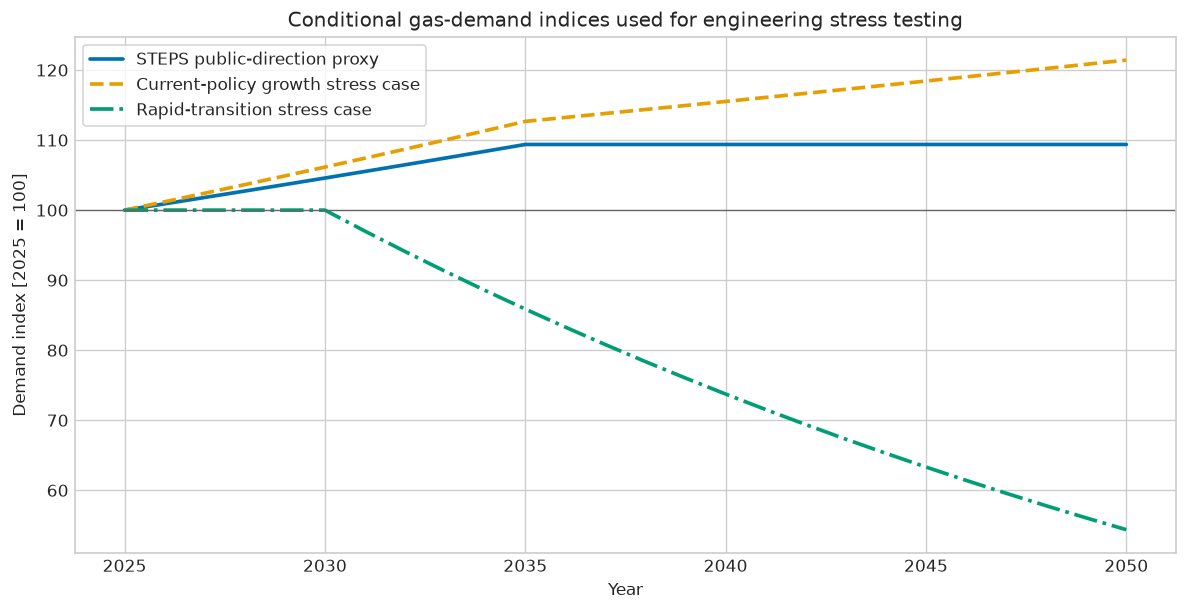

In [7]:
fig, ax = plt.subplots(figsize=(10.0, 5.2))

scenario_styles = [
    (COLORS["blue"], "-"),
    (COLORS["orange"], "--"),
    (COLORS["green"], "-."),
]

for column_name, style in zip(
    scenario_indices.columns[1:],
    scenario_styles,
):
    ax.plot(
        scenario_indices["year"],
        scenario_indices[column_name],
        label=column_name,
        color=style[0],
        linestyle=style[1],
        linewidth=2.2,
    )

ax.axhline(100.0, color=COLORS["grey"], linewidth=0.8)
ax.set_title("Conditional gas-demand indices used for engineering stress testing")
ax.set_xlabel("Year")
ax.set_ylabel("Demand index [2025 = 100]")
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

**Interpretation.** The range is more useful for capacity-risk discussion than a single
forecast. Long-lived infrastructure faces both utilisation risk in a rapid transition and
expansion pressure under continued growth. These curves are reproducible assumptions,
deliberately separated from licensed WEO numbers.

## 4. LNG is reshaping long-distance gas trade

WEO 2025 and *Gas 2025* identify about 300 bcm/year of LNG export capacity scheduled by
2030—roughly a 50% increase in available global LNG supply. About 70% of additions are in
the United States and Qatar. Gross capacity is not the same as net supply: ramp-up,
utilisation, and declines at legacy plants reduce the projected net increase to about
250 bcm/year.

In [8]:
lng_capacity = pd.DataFrame(
    {
        "metric": [
            "Implied available LNG supply before additions",
            "Gross new export capacity by 2030",
            "Projected net LNG supply increase by 2030",
        ],
        "value_bcm_per_year": [
            600.0,
            300.0,
            250.0,
        ],
    }
)

implied_2030_capacity_bcm_per_year = 600.0 + 300.0
net_realisation_fraction = 250.0 / 300.0

display(lng_capacity)
print(
    "Net supply increase / gross capacity addition: "
    f"{100.0 * net_realisation_fraction:.1f}%"
)

assert math.isclose(implied_2030_capacity_bcm_per_year, 900.0)

Net supply increase / gross capacity addition: 83.3%


,metric,value_bcm_per_year
0,Implied available LNG supply before additions,600.0
1,Gross new export capacity by 2030,300.0
2,Projected net LNG supply increase by 2030,250.0


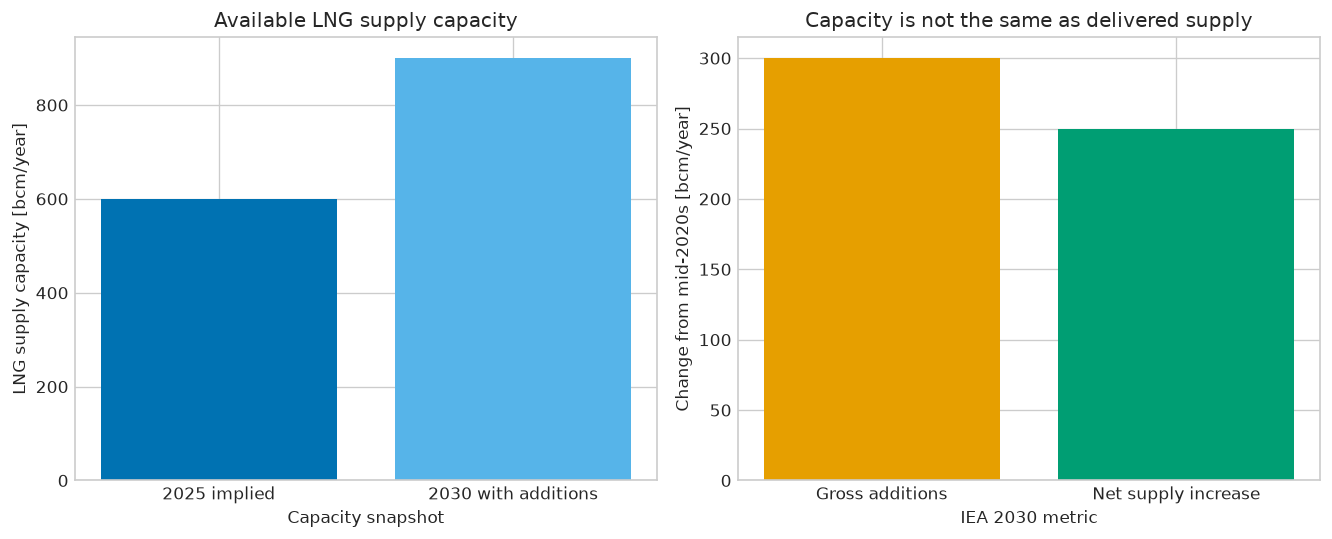

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.6))

axes[0].bar(
    ["2025 implied", "2030 with additions"],
    [600.0, 900.0],
    color=[COLORS["blue"], COLORS["sky"]],
)
axes[0].set_title("Available LNG supply capacity")
axes[0].set_xlabel("Capacity snapshot")
axes[0].set_ylabel("LNG supply capacity [bcm/year]")

axes[1].bar(
    ["Gross additions", "Net supply increase"],
    [300.0, 250.0],
    color=[COLORS["orange"], COLORS["green"]],
)
axes[1].set_title("Capacity is not the same as delivered supply")
axes[1].set_xlabel("IEA 2030 metric")
axes[1].set_ylabel("Change from mid-2020s [bcm/year]")

fig.tight_layout()
plt.show()

**Interpretation.** The 50 bcm/year difference between gross additions and net supply
growth is a reminder to model ramp-up and utilisation. Nameplate capacity should never be
treated as guaranteed annual throughput.

## 5. Environmental boundary: combustion is not the whole story

Natural gas produces carbon dioxide when burned, while methane can be emitted during
production, processing, and transport. The IEA estimated 36 Mt of methane from natural-gas
operations in 2025 and an average upstream oil-and-gas methane intensity near 1%.

A lifecycle screen must therefore state:

- gas composition and calorific-value basis;
- power-generation efficiency;
- methane-loss fraction and climate metric;
- whether compression, liquefaction, and transport energy are included.

## 6. NeqSim model architecture

The practical workflow uses real NeqSim functionality:

`composition → SRK fluid → TP flash → ISO 6976 → stream → compressors → intercoolers`

The Soave–Redlich–Kwong equation of state is suitable for a dry, non-polar natural-gas
screening calculation. A TP flash establishes the stable phase at specified temperature
and pressure. ISO 6976 then calculates gas-quality quantities from the same composition.
Process equipment clones and transforms streams while preserving composition and mass.

For a mixture, mole fractions must satisfy:

$$
\sum_i z_i = 1
$$

$z_i$ is the mole fraction of component $i$. The representative composition is synthetic,
public, and intended for teaching—not custody transfer or commercial design.

In [10]:
composition = {
    "methane": 0.895,
    "ethane": 0.060,
    "propane": 0.020,
    "n-butane": 0.006,
    "i-butane": 0.004,
    "nitrogen": 0.010,
    "CO2": 0.005,
}

composition_sum = sum(composition.values())
assert math.isclose(
    composition_sum,
    1.0,
    rel_tol=0.0,
    abs_tol=1.0e-12,
)

export_gas = fluid(
    "srk",
    temperature=288.15,
    pressure=5.0,
)

for component_name, mole_fraction in composition.items():
    export_gas.addComponent(
        component_name,
        mole_fraction,
    )

export_gas.setMixingRule("classic")
TPflash(export_gas)

print(f"Composition sum: {composition_sum:.9f} mol/mol")
print(f"Equilibrium phases: {export_gas.getNumberOfPhases()}")

assert export_gas.getNumberOfPhases() == 1

Composition sum: 1.000000000 mol/mol
Equilibrium phases: 1


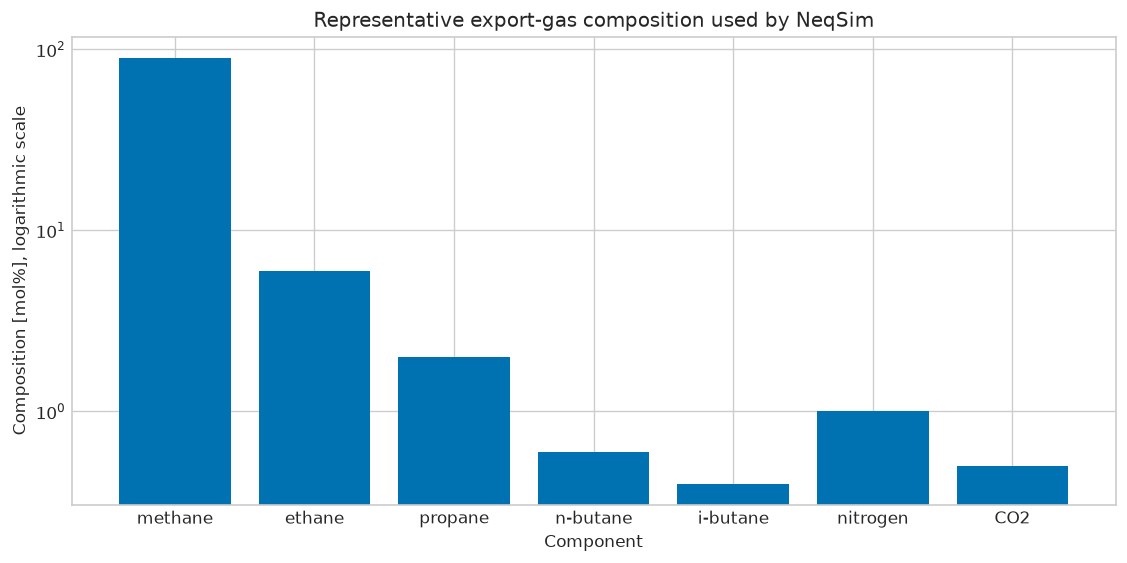

In [11]:
composition_table = pd.DataFrame(
    {
        "component": list(composition.keys()),
        "mole_percent": 100.0 * np.array(list(composition.values())),
    }
)

fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.bar(
    composition_table["component"],
    composition_table["mole_percent"],
    color=COLORS["blue"],
)
ax.set_yscale("log")
ax.set_title("Representative export-gas composition used by NeqSim")
ax.set_xlabel("Component")
ax.set_ylabel("Composition [mol%], logarithmic scale")
plt.tight_layout()
plt.show()

**Interpretation.** Methane dominates, but ethane and propane increase energy content.
Nitrogen and carbon dioxide are non-combustible diluents. The logarithmic scale keeps trace
and major components visible without changing the underlying composition.

## 7. Flash and inspect the gas state

A TP flash solves phase equilibrium at fixed temperature and pressure. NeqSim then exposes
density, compressibility, molar mass, enthalpy, and other properties needed by process
equipment. The screening state is 15°C and 5 bara.

In [12]:
export_gas.initPhysicalProperties()

state_properties = pd.DataFrame(
    {
        "quantity": [
            "Temperature",
            "Pressure",
            "Density",
            "Compressibility factor",
            "Molar mass",
        ],
        "value": [
            export_gas.getTemperature("C"),
            export_gas.getPressure("bara"),
            export_gas.getDensity("kg/m3"),
            export_gas.getZ(),
            1000.0 * export_gas.getMolarMass("kg/mol"),
        ],
        "unit": [
            "°C",
            "bara",
            "kg/m³",
            "1",
            "g/mol",
        ],
    }
)

display(state_properties)

assert 0.8 < export_gas.getZ() < 1.1
assert export_gas.getDensity("kg/m3") > 0.0

,quantity,value,unit
0,Temperature,15.000000,°C
1,Pressure,5.000000,bara
2,Density,3.831238,kg/m³
3,Compressibility factor,0.987576,1
4,Molar mass,18.126040,g/mol


## 8. ISO 6976 calorific value and Wobbe index

ISO 6976 evaluates combustion properties at stated reference conditions. Standard volume
here means 15°C and 1.01325 bara.

$$
E = V_s H_{i,s}
$$

$E$ is fuel energy in MJ, $V_s$ is standard volume in $\mathrm{Sm^3}$, and $H_{i,s}$ is
inferior calorific value in $\mathrm{MJ/Sm^3}$.

In [13]:
iso_volume = ISO6976(
    export_gas,
    numberunit="volume",
    referencetemperaturevolume="15",
    referencetemperaturecombustion="15",
)
iso_mass = ISO6976(
    export_gas,
    numberunit="mass",
    referencetemperaturevolume="15",
    referencetemperaturecombustion="15",
)

lhv_mj_per_sm3 = iso_volume.getValue("InferiorCalorificValue") / 1000.0
hhv_mj_per_sm3 = iso_volume.getValue("SuperiorCalorificValue") / 1000.0
wobbe_mj_per_sm3 = iso_volume.getValue("SuperiorWobbeIndex") / 1000.0
relative_density = iso_volume.getValue("RelativeDensity")
lhv_mj_per_kg = iso_mass.getValue("InferiorCalorificValue") / 1000.0

gas_quality = pd.DataFrame(
    {
        "quantity": [
            "Inferior calorific value",
            "Superior calorific value",
            "Superior Wobbe index",
            "Relative density",
            "Inferior calorific value",
        ],
        "value": [
            lhv_mj_per_sm3,
            hhv_mj_per_sm3,
            wobbe_mj_per_sm3,
            relative_density,
            lhv_mj_per_kg,
        ],
        "unit": [
            "MJ/Sm³",
            "MJ/Sm³",
            "MJ/Sm³",
            "kg/kg",
            "MJ/kg",
        ],
    }
)

display(gas_quality)

assert 30.0 < lhv_mj_per_sm3 < 45.0
assert hhv_mj_per_sm3 > lhv_mj_per_sm3
assert wobbe_mj_per_sm3 > hhv_mj_per_sm3

,quantity,value,unit
0,Inferior calorific value,36.954244,MJ/Sm³
1,Superior calorific value,40.910789,MJ/Sm³
2,Superior Wobbe index,51.660802,MJ/Sm³
3,Relative density,0.627124,kg/kg
4,Inferior calorific value,48.082462,MJ/kg


## 9. Translate bcm/year into energy and mass flow

Consider a 10 bcm/year terminal tranche. Calendar-average flow is used only for screening:

$$
\dot V_s = \frac{V_{s,year}}{t_{year}}
$$

$\dot V_s$ is standard flow in $\mathrm{Sm^3/s}$ and $t_{year}$ is seconds per year.
Availability, seasonal swings, and linepack are excluded.

In [14]:
annual_volume_bcm = 10.0
seconds_per_year = 365.25 * 24.0 * 3600.0
standard_flow_sm3_s = annual_volume_bcm * 1.0e9 / seconds_per_year

standard_gas = export_gas.clone()
standard_gas.setTemperature(288.15)
standard_gas.setPressure(1.01325)
TPflash(standard_gas)
standard_gas.initPhysicalProperties()

standard_density_kg_m3 = standard_gas.getDensity("kg/m3")
average_mass_flow_kg_s = standard_flow_sm3_s * standard_density_kg_m3
annual_energy_pj = annual_volume_bcm * lhv_mj_per_sm3

throughput_results = pd.DataFrame(
    {
        "quantity": [
            "Annual standard volume",
            "Average standard flow",
            "Standard density",
            "Average mass flow",
            "Annual fuel energy",
        ],
        "value": [
            annual_volume_bcm,
            standard_flow_sm3_s,
            standard_density_kg_m3,
            average_mass_flow_kg_s,
            annual_energy_pj,
        ],
        "unit": [
            "bcm/year",
            "Sm³/s",
            "kg/Sm³",
            "kg/s",
            "PJ/year",
        ],
    }
)

display(throughput_results)

assert average_mass_flow_kg_s > 0.0
assert annual_energy_pj > 300.0

,quantity,value,unit
0,Annual standard volume,10.000000,bcm/year
1,Average standard flow,316.880878,Sm³/s
2,Standard density,0.768565,kg/Sm³
3,Average mass flow,243.543706,kg/s
4,Annual fuel energy,369.542441,PJ/year


## 10. Final application: three-stage intercooled compression

The terminal raises gas pressure from 5 to 80 bara in three equal pressure-ratio stages.
Each compressor has 78% isentropic efficiency and each intercooler returns gas to 30°C.
This demonstrates NeqSim streams, compressors, coolers, a `ProcessSystem`, result access,
and conservation checks.

Equal stage pressure ratio is:

$$
r_p = \left(\frac{p_{out}}{p_{in}}\right)^{1/N}
$$

$N$ is the number of stages and pressures are absolute.

In [15]:
inlet_pressure_bara = 5.0
outlet_pressure_bara = 80.0
stage_count = 3
stage_pressure_ratio = (
    outlet_pressure_bara / inlet_pressure_bara
) ** (1.0 / stage_count)

stage_pressures_bara = [
    inlet_pressure_bara * stage_pressure_ratio ** stage_number
    for stage_number in range(1, stage_count + 1)
]

print(f"Equal stage pressure ratio: {stage_pressure_ratio:.6f}")
print(
    "Stage discharge pressures: "
    + ", ".join(
        f"{pressure:.3f} bara"
        for pressure in stage_pressures_bara
    )
)

assert math.isclose(
    stage_pressures_bara[-1],
    outlet_pressure_bara,
    rel_tol=1.0e-12,
)

Equal stage pressure ratio: 2.519842
Stage discharge pressures: 12.599 bara, 31.748 bara, 80.000 bara


In [16]:
process = newProcess("Scenario-linked terminal compression")

feed_stream = stream(
    "Terminal feed",
    export_gas.clone(),
    process=process,
)
feed_stream.setFlowRate(
    average_mass_flow_kg_s,
    "kg/sec",
)

compressors = []
intercoolers = []
current_stream = feed_stream

for stage_number, discharge_pressure in enumerate(
    stage_pressures_bara,
    start=1,
):
    stage_compressor = compressor(
        f"Compressor stage {stage_number}",
        current_stream,
        pres=discharge_pressure,
        process=process,
    )
    stage_compressor.setIsentropicEfficiency(0.78)

    stage_cooler = cooler(
        f"Intercooler stage {stage_number}",
        stage_compressor.getOutletStream(),
        process=process,
    )
    stage_cooler.setOutTemperature(303.15)

    compressors.append(stage_compressor)
    intercoolers.append(stage_cooler)
    current_stream = stage_cooler.getOutletStream()

process.run()

In [17]:
stage_rows = []

for stage_number, (stage_compressor, stage_cooler) in enumerate(
    zip(compressors, intercoolers),
    start=1,
):
    stage_rows.append(
        {
            "stage": stage_number,
            "discharge_pressure_bara": (
                stage_compressor.getOutletStream().getPressure("bara")
            ),
            "compressor_outlet_c": (
                stage_compressor.getOutletStream().getTemperature("C")
            ),
            "cooler_outlet_c": (
                stage_cooler.getOutletStream().getTemperature("C")
            ),
            "compressor_power_mw": stage_compressor.getPower() / 1.0e6,
            "cooler_duty_mw": stage_cooler.getDuty() / 1.0e6,
        }
    )

stage_results = pd.DataFrame(stage_rows)
total_compressor_power_mw = stage_results["compressor_power_mw"].sum()

display(stage_results)
print(f"Total compressor power: {total_compressor_power_mw:.6f} MW")

assert total_compressor_power_mw > 0.0
assert (stage_results["cooler_duty_mw"] < 0.0).all()

Total compressor power: 127.037196 MW


,stage,discharge_pressure_bara,compressor_outlet_c,cooler_outlet_c,compressor_power_mw,cooler_duty_mw
0,1,12.599210,94.827186,30.0,41.712455,-35.957875
1,2,31.748021,112.833209,30.0,43.302945,-48.504908
2,3,80.000000,114.411392,30.0,42.021795,-55.392779


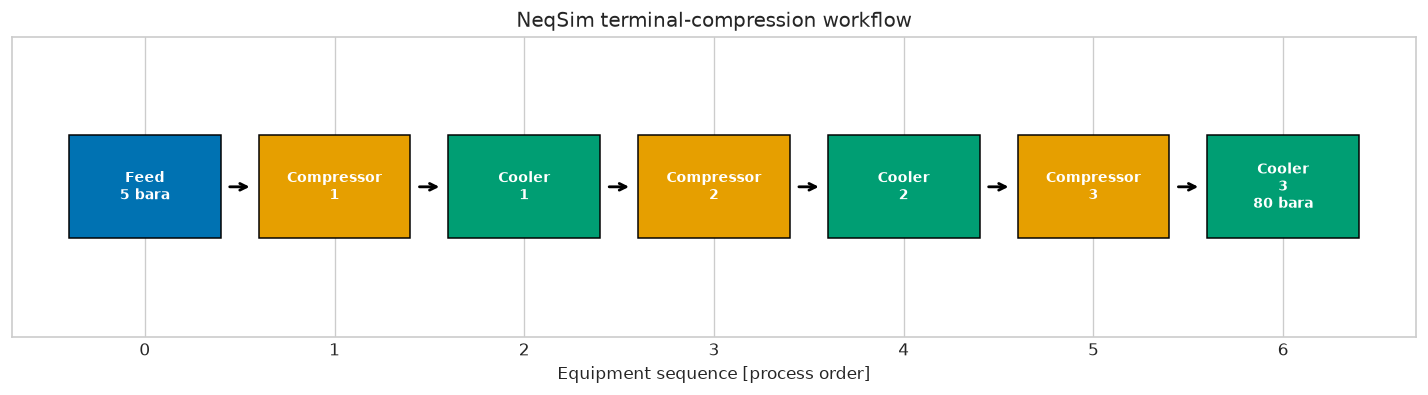

In [18]:
workflow_x = np.arange(7)
workflow_labels = [
    "Feed\n5 bara",
    "Compressor\n1",
    "Cooler\n1",
    "Compressor\n2",
    "Cooler\n2",
    "Compressor\n3",
    "Cooler\n3\n80 bara",
]
workflow_colors = [
    COLORS["blue"],
    COLORS["orange"],
    COLORS["green"],
    COLORS["orange"],
    COLORS["green"],
    COLORS["orange"],
    COLORS["green"],
]

fig, ax = plt.subplots(figsize=(12.0, 3.4))

for x_value, label, color in zip(
    workflow_x,
    workflow_labels,
    workflow_colors,
):
    box = plt.Rectangle(
        (x_value - 0.40, -0.24),
        0.80,
        0.48,
        facecolor=color,
        edgecolor="black",
        linewidth=0.9,
        zorder=3,
    )
    ax.add_patch(box)
    ax.text(
        x_value,
        0.0,
        label,
        ha="center",
        va="center",
        color="white",
        fontsize=8.5,
        weight="bold",
        zorder=4,
    )

for start, end in zip(workflow_x[:-1], workflow_x[1:]):
    ax.annotate(
        "",
        xy=(end - 0.43, 0.0),
        xytext=(start + 0.43, 0.0),
        arrowprops={
            "arrowstyle": "->",
            "linewidth": 1.7,
        },
    )

ax.set_title("NeqSim terminal-compression workflow")
ax.set_xlabel("Equipment sequence [process order]")
ax.set_xlim(-0.7, 6.7)
ax.set_ylim(-0.7, 0.7)
ax.set_yticks([])
plt.tight_layout()
plt.show()

**Interpretation.** Intercooling lowers the inlet temperature of each following stage,
reducing specific compression work and limiting discharge temperature. Real design also
needs pressure drop, compressor maps, drivers, redundancy, surge control, and availability.

## 11. Conservation checks

For each adiabatic compressor:

$$
\dot W = \dot H_{out} - \dot H_{in}
$$

$\dot W$ is shaft power and $\dot H$ is stream enthalpy rate, both in W. The overall
process must also preserve mass flow.

In [19]:
compressor_energy_residuals_w = []

for stage_compressor in compressors:
    inlet_enthalpy_w = stage_compressor.getInletStream().getFluid().getEnthalpy()
    outlet_enthalpy_w = (
        stage_compressor.getOutletStream().getFluid().getEnthalpy()
    )
    residual_w = (
        outlet_enthalpy_w
        - inlet_enthalpy_w
        - stage_compressor.getPower()
    )
    compressor_energy_residuals_w.append(residual_w)

product_stream = intercoolers[-1].getOutletStream()
mass_residual_kg_s = (
    product_stream.getFlowRate("kg/sec")
    - feed_stream.getFlowRate("kg/sec")
)
maximum_energy_residual_w = max(
    abs(value)
    for value in compressor_energy_residuals_w
)

print(f"Mass residual: {mass_residual_kg_s:.3e} kg/s")
print(
    "Maximum compressor energy residual: "
    f"{maximum_energy_residual_w:.3e} W"
)

assert abs(mass_residual_kg_s) < 1.0e-9
assert maximum_energy_residual_w < 1.0e-5

Mass residual: 0.000e+00 kg/s
Maximum compressor energy residual: 0.000e+00 W


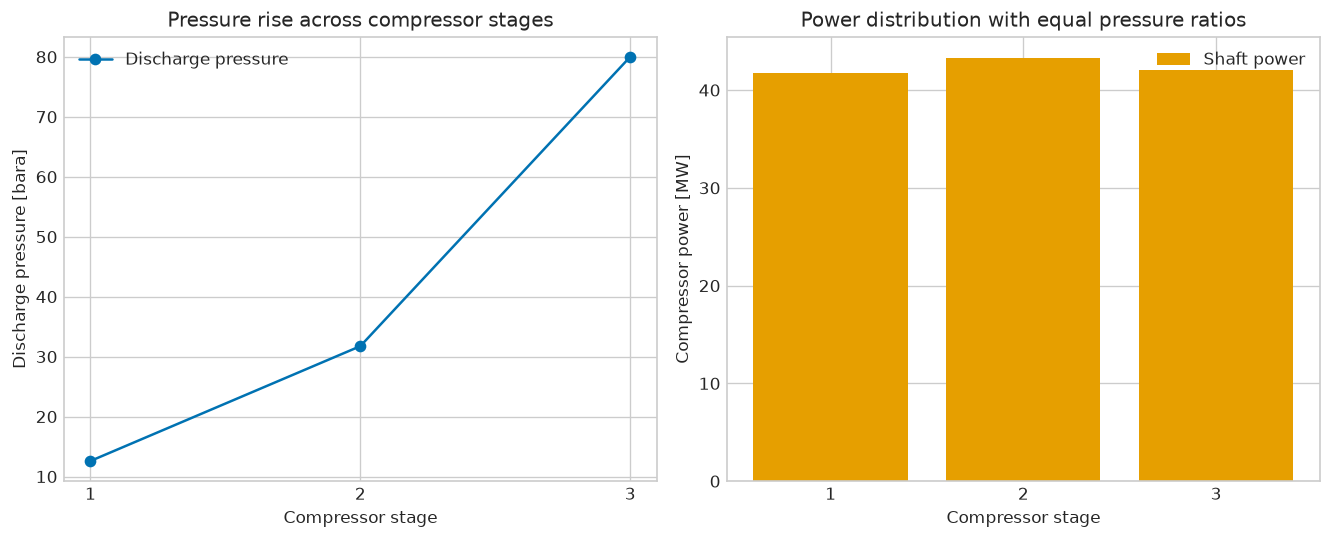

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.6))

axes[0].plot(
    stage_results["stage"],
    stage_results["discharge_pressure_bara"],
    marker="o",
    color=COLORS["blue"],
    label="Discharge pressure",
)
axes[0].set_title("Pressure rise across compressor stages")
axes[0].set_xlabel("Compressor stage")
axes[0].set_ylabel("Discharge pressure [bara]")
axes[0].set_xticks(stage_results["stage"])
axes[0].legend()

axes[1].bar(
    stage_results["stage"],
    stage_results["compressor_power_mw"],
    color=COLORS["orange"],
    label="Shaft power",
)
axes[1].set_title("Power distribution with equal pressure ratios")
axes[1].set_xlabel("Compressor stage")
axes[1].set_ylabel("Compressor power [MW]")
axes[1].set_xticks(stage_results["stage"])
axes[1].legend()

fig.tight_layout()
plt.show()

**Interpretation.** Similar stage powers indicate that equal pressure ratios and complete
intercooling are a reasonable first screening choice. The rising absolute pressure remains
explicit; equal ratios do not mean equal pressure increments.

## 12. Reusable pressure sensitivity

A reusable function makes the workflow practical. It clones the same gas, builds a fresh
`ProcessSystem`, varies final pressure, runs every unit, and returns power and maximum
temperature. This avoids hidden state between scenarios.

In [21]:
def run_compression_case(final_pressure_bara, flow_kg_s):
    case_process = newProcess(
        f"Compression to {final_pressure_bara:.0f} bara"
    )
    case_feed = stream(
        "Case feed",
        export_gas.clone(),
        process=case_process,
    )
    case_feed.setFlowRate(
        flow_kg_s,
        "kg/sec",
    )

    case_ratio = (
        final_pressure_bara / inlet_pressure_bara
    ) ** (1.0 / stage_count)
    case_stream = case_feed
    case_compressors = []

    for stage_number in range(1, stage_count + 1):
        case_pressure = inlet_pressure_bara * case_ratio ** stage_number
        case_compressor = compressor(
            f"Case compressor {stage_number}",
            case_stream,
            pres=case_pressure,
            process=case_process,
        )
        case_compressor.setIsentropicEfficiency(0.78)

        case_cooler = cooler(
            f"Case cooler {stage_number}",
            case_compressor.getOutletStream(),
            process=case_process,
        )
        case_cooler.setOutTemperature(303.15)

        case_compressors.append(case_compressor)
        case_stream = case_cooler.getOutletStream()

    case_process.run()

    case_power_mw = sum(
        item.getPower()
        for item in case_compressors
    ) / 1.0e6
    case_maximum_temperature_c = max(
        item.getOutletStream().getTemperature("C")
        for item in case_compressors
    )

    return {
        "final_pressure_bara": final_pressure_bara,
        "power_mw": case_power_mw,
        "maximum_discharge_c": case_maximum_temperature_c,
    }

In [22]:
pressure_cases_bara = [50.0, 65.0, 80.0, 95.0]
sensitivity_results = pd.DataFrame(
    [
        run_compression_case(
            final_pressure,
            average_mass_flow_kg_s,
        )
        for final_pressure in pressure_cases_bara
    ]
)

display(sensitivity_results)

assert sensitivity_results["power_mw"].is_monotonic_increasing
assert sensitivity_results["maximum_discharge_c"].max() < 125.0

,final_pressure_bara,power_mw,maximum_discharge_c
0,50.0,104.205058,99.056496
1,65.0,116.884987,107.577944
2,80.0,127.037196,114.411392
3,95.0,135.526830,120.106496


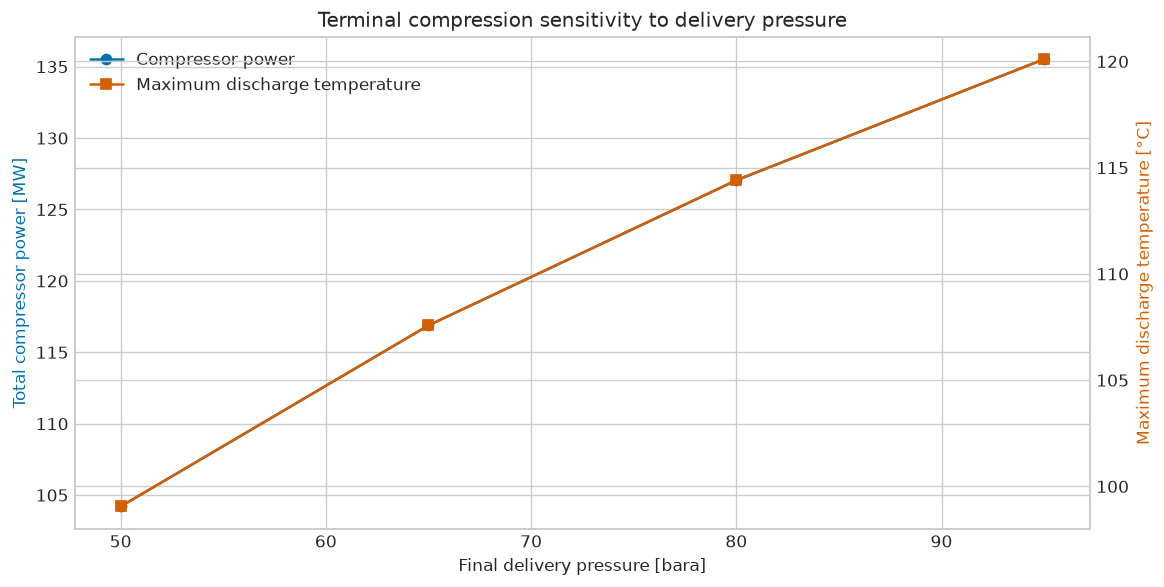

In [23]:
fig, ax_left = plt.subplots(figsize=(9.8, 5.0))
ax_right = ax_left.twinx()

power_line = ax_left.plot(
    sensitivity_results["final_pressure_bara"],
    sensitivity_results["power_mw"],
    marker="o",
    color=COLORS["blue"],
    label="Compressor power",
)
temperature_line = ax_right.plot(
    sensitivity_results["final_pressure_bara"],
    sensitivity_results["maximum_discharge_c"],
    marker="s",
    color=COLORS["red"],
    label="Maximum discharge temperature",
)

ax_left.set_title("Terminal compression sensitivity to delivery pressure")
ax_left.set_xlabel("Final delivery pressure [bara]")
ax_left.set_ylabel("Total compressor power [MW]", color=COLORS["blue"])
ax_right.set_ylabel(
    "Maximum discharge temperature [°C]",
    color=COLORS["red"],
)

combined_lines = power_line + temperature_line
ax_left.legend(
    combined_lines,
    [line.get_label() for line in combined_lines],
    loc="upper left",
)
plt.tight_layout()
plt.show()

**Interpretation.** Both power and discharge temperature increase with delivery pressure.
This trend check is more important than the exact screening values: a reversed trend would
signal a model, unit, or state-management error.

## 13. Combustion and methane-boundary screen

Carbon atoms in the gas determine direct carbon dioxide. A power-plant efficiency of 58%
is an illustrative modern combined-cycle assumption. Methane losses are added with a
100-year global-warming potential of 29.8 as a transparent scenario parameter.

$$
I_{CO_2} = \frac{m_{CO_2}/m_f}{\eta H_i/3600}
$$

$I_{CO_2}$ is in $\mathrm{kg/MWh_e}$, $m_f$ is fuel mass, $\eta$ is electrical
efficiency, and $H_i$ is inferior calorific value in MJ/kg.

In [24]:
carbon_atoms = {
    "methane": 1,
    "ethane": 2,
    "propane": 3,
    "n-butane": 4,
    "i-butane": 4,
    "CO2": 1,
    "nitrogen": 0,
}

carbon_moles_per_mole_gas = sum(
    composition[component] * carbon_atoms[component]
    for component in composition
)
gas_molar_mass_kg_mol = export_gas.getMolarMass("kg/mol")
co2_kg_per_kg_gas = (
    carbon_moles_per_mole_gas
    * 0.0440095
    / gas_molar_mass_kg_mol
)

electrical_efficiency = 0.58
electricity_mwh_per_kg = (
    electrical_efficiency * lhv_mj_per_kg / 3600.0
)
direct_co2_kg_per_mwh = (
    co2_kg_per_kg_gas / electricity_mwh_per_kg
)

print(f"Direct CO₂ factor: {direct_co2_kg_per_mwh:.3f} kg/MWhₑ")

assert 300.0 < direct_co2_kg_per_mwh < 500.0

Direct CO₂ factor: 351.034 kg/MWhₑ


In [25]:
methane_loss_fractions = np.array([0.002, 0.005, 0.010, 0.020])
methane_gwp100 = 29.8
methane_mass_fraction = (
    composition["methane"]
    * 0.0160425
    / gas_molar_mass_kg_mol
)

methane_co2e_kg_per_mwh = (
    methane_loss_fractions
    * methane_mass_fraction
    * methane_gwp100
    / electricity_mwh_per_kg
)

emissions_sensitivity = pd.DataFrame(
    {
        "upstream_methane_intensity_percent": (
            100.0 * methane_loss_fractions
        ),
        "direct_co2_kg_per_mwh": direct_co2_kg_per_mwh,
        "methane_co2e_kg_per_mwh": methane_co2e_kg_per_mwh,
    }
)
emissions_sensitivity["combined_kg_co2e_per_mwh"] = (
    emissions_sensitivity["direct_co2_kg_per_mwh"]
    + emissions_sensitivity["methane_co2e_kg_per_mwh"]
)

display(emissions_sensitivity.round(2))
assert emissions_sensitivity["combined_kg_co2e_per_mwh"].is_monotonic_increasing

,upstream_methane_intensity_percent,direct_co2_kg_per_mwh,methane_co2e_kg_per_mwh,combined_kg_co2e_per_mwh
0,0.2,351.03,6.09,357.13
1,0.5,351.03,15.24,366.27
2,1.0,351.03,30.47,381.51
3,2.0,351.03,60.94,411.98


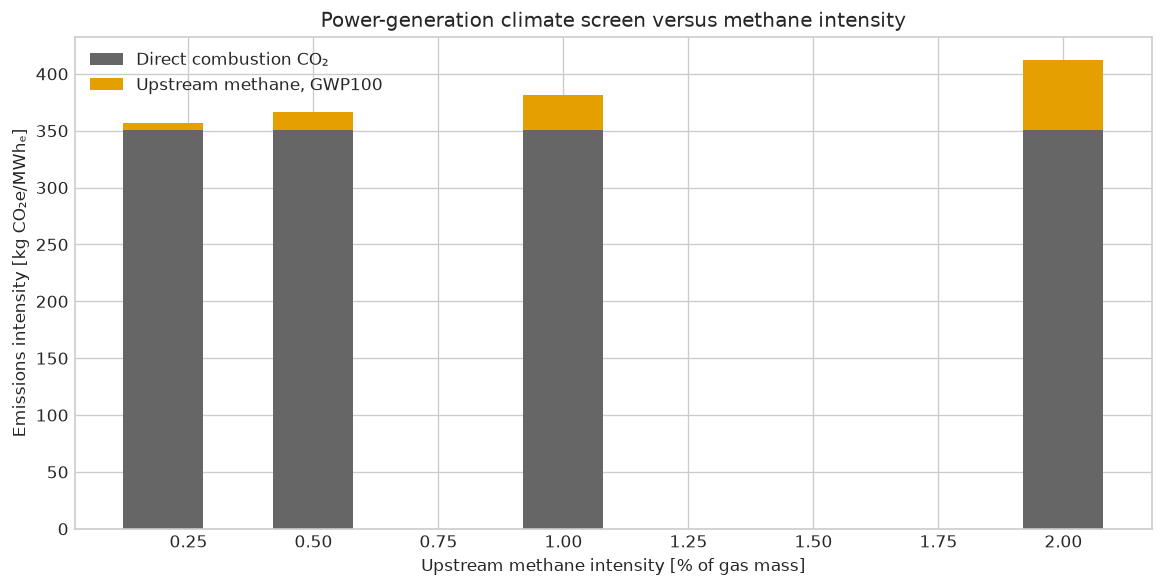

In [26]:
fig, ax = plt.subplots(figsize=(9.8, 5.0))

ax.bar(
    emissions_sensitivity["upstream_methane_intensity_percent"],
    emissions_sensitivity["direct_co2_kg_per_mwh"],
    width=0.16,
    color=COLORS["grey"],
    label="Direct combustion CO₂",
)
ax.bar(
    emissions_sensitivity["upstream_methane_intensity_percent"],
    emissions_sensitivity["methane_co2e_kg_per_mwh"],
    width=0.16,
    bottom=emissions_sensitivity["direct_co2_kg_per_mwh"],
    color=COLORS["orange"],
    label="Upstream methane, GWP100",
)

ax.set_title("Power-generation climate screen versus methane intensity")
ax.set_xlabel("Upstream methane intensity [% of gas mass]")
ax.set_ylabel("Emissions intensity [kg CO₂e/MWhₑ]")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation.** Direct combustion dominates this 100-year screen, but methane
performance materially changes the total. The IEA's 2026 tracker shows both a large
mitigation opportunity and wide producer-to-producer variation. Procurement and design
decisions therefore need measured supply-chain data, not a universal leakage factor.

## 14. Consolidated validation

The checks below make hidden assumptions visible: single gas phase, normal gas quality,
monotonic pressure sensitivity, process conservation, finite outputs, and scenario-table
integrity. Passing them supports reproducibility; it does not certify a facility design.

In [27]:
final_checks = {
    "composition_closes": abs(composition_sum - 1.0) < 1.0e-12,
    "single_gas_phase": export_gas.getNumberOfPhases() == 1,
    "positive_lhv": lhv_mj_per_sm3 > 0.0,
    "hhv_above_lhv": hhv_mj_per_sm3 > lhv_mj_per_sm3,
    "positive_terminal_flow": average_mass_flow_kg_s > 0.0,
    "mass_balance": abs(mass_residual_kg_s) < 1.0e-9,
    "energy_balances": maximum_energy_residual_w < 1.0e-5,
    "power_trend": sensitivity_results["power_mw"].is_monotonic_increasing,
    "finite_results": np.isfinite(
        [
            lhv_mj_per_sm3,
            total_compressor_power_mw,
            direct_co2_kg_per_mwh,
        ]
    ).all(),
    "scenario_indices_positive": (
        scenario_indices.drop(columns="year") > 0.0
    ).all().all(),
}

validation_table = pd.DataFrame(
    {
        "check": list(final_checks.keys()),
        "passed": list(final_checks.values()),
    }
)

display(validation_table)
assert all(final_checks.values())
print(f"All {len(final_checks)} consolidated checks passed.")

All 10 consolidated checks passed.


,check,passed
0,composition_closes,True
1,single_gas_phase,True
2,positive_lhv,True
3,hhv_above_lhv,True
4,positive_terminal_flow,True
5,mass_balance,True
6,energy_balances,True
7,power_trend,True
8,finite_results,True
9,scenario_indices_positive,True


## 15. Limitations and applicability

This notebook is appropriate for education, order-of-magnitude infrastructure screening,
and transparent scenario comparison. It is not sufficient for investment approval,
compressor selection, custody transfer, or lifecycle certification.

Key omissions include hourly demand, storage and linepack, LNG boil-off, liquefaction and
shipping energy, pressure drop, compressor maps, degradation, outages, costs, policy risk,
carbon capture, and measured supplier-specific methane. WEO scenarios are conditional and
should not be assigned probabilities without a separate decision framework.

## Troubleshooting

- **NeqSim import fails in Colab:** rerun the setup cell, then restart the runtime only if
  Colab explicitly requests it.
- **A flash produces liquid:** check temperature, pressure, composition, and heavy
  components before assuming a dry-gas compressor.
- **Compression does not converge:** reduce the pressure ratio, verify a single gas phase,
  and initialise each case from a fresh fluid clone.
- **ISO 6976 values look wrong:** verify reference conditions and whether the requested
  basis is mass or standard volume.
- **Statistics disagree with another source:** compare publication date, geographical
  coverage, standard conditions, revisions, and the distinction between demand and supply.

## Summary

- Global gas-demand growth slowed from 2.8% in 2024 to about 1% in 2025.
- Regional outcomes diverged, so one global growth rate is not a design basis.
- WEO scenarios are conditional pathways; the notebook keeps public statements separate
  from explicit engineering stress cases.
- Roughly 300 bcm/year of LNG capacity is scheduled by 2030, versus about 250 bcm/year of
  projected net supply growth.
- NeqSim connected composition, phase equilibrium, ISO 6976 gas quality, standard-volume
  conversion, multistage compression, balance checks, sensitivity, and emissions.
- Methane intensity is a material, supplier-dependent lifecycle parameter.

## Further exercises

1. Replace the stress-case rates with data you are licensed to use from WEO scenario tables.
2. Add seasonal load factors and size storage or linepack for peak demand.
3. Compare SRK and Peng–Robinson predictions for compression power.
4. Add pressure drops, compressor maps, and an availability model.
5. Compare pipeline delivery with LNG liquefaction, shipping, and regasification energy.
6. Replace the methane assumptions with measured supplier-specific intensities.
7. Add biomethane or hydrogen blends and inspect Wobbe-index constraints.

## References

- [IEA, World Energy Outlook 2025 — overview and key findings](https://www.iea.org/reports/world-energy-outlook-2025/overview-and-key-findings)
- [IEA, World Energy Outlook 2025 — Stated Policies Scenario](https://www.iea.org/reports/world-energy-outlook-2025/stated-policies-scenario)
- [IEA, World Energy Outlook 2025 — Net Zero Emissions by 2050](https://www.iea.org/reports/world-energy-outlook-2025/net-zero-emissions-by-2050)
- [IEA, Gas 2025 — executive summary](https://www.iea.org/reports/gas-2025/executive-summary)
- [IEA, Global Energy Review 2026 — natural gas](https://www.iea.org/reports/global-energy-review-2026/natural-gas)
- [IEA, Global Methane Tracker 2026 — key findings](https://www.iea.org/reports/global-methane-tracker-2026/key-findings)
- [NeqSim Python documentation](https://neqsim.readthedocs.io/en/latest/)
- [NeqSim source repository](https://github.com/equinor/neqsim)
- ISO 6976:2016, *Natural gas — Calculation of calorific values, density, relative density
  and Wobbe indices from composition*.